In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import coherent
from scipy.special import erfc

In [2]:
# Parameters

alpha = 0.7

# Number of time bins
M = 100

# Number of Monte Carlo trials for each input state
n_trials = 5000

# Equal prior probabilities
P_plus_initial = 0.5
P_minus_initial = 0.5

In [3]:
# Hilbert space dimension
N = 30

# The two possible coherent states
psi_plus = coherent(N, alpha)
psi_minus = coherent(N, -alpha)

In [4]:
def click_probabilities(amplitude):
    """
    Calculates the probabilities of a no-clickand click event for a coherent state.

    Parameters amplitude - complex
        Coherent-state amplitude at the detector.

    Returns
    P_no_click, P_click
    """

    mean_photons = np.abs(amplitude)**2

    P_no_click = np.exp(-mean_photons)

    P_click = 1 - P_no_click

    return P_no_click, P_click

In [ ]:
def bayesian_update(P_plus, P_minus, likelihood_plus, likelihood_minus):
    """
    Updates the probabilities of the two hypotheses using Bayes' rule.
    """

    numerator_plus = likelihood_plus * P_plus
    numerator_minus = likelihood_minus * P_minus

    normalization = (numerator_plus + numerator_minus)

    P_plus_new = numerator_plus / normalization
    P_minus_new = numerator_minus / normalization

    return P_plus_new, P_minus_new

In [6]:
def choose_displacement(P_plus, P_minus, alpha_bin):
    """
    Chooses a displacement that nulls the currently most likely hypothesis.
    """

    if P_plus >= P_minus:

        # Null |+alpha_bin>
        beta = -alpha_bin

    else:

        # Null |-alpha_bin>
        beta = alpha_bin

    return beta

In [7]:
def adaptive_receiver(true_state, alpha, M, store_history=False):
    """
    Simulates a discrete adaptive receiver.

    Parameters:
    true_state : int
        +1 for |+alpha>
        -1 for |-alpha>

    alpha : float
        Coherent-state amplitude.

    M : int
        Number of time bins.

    store_history : bool
        If True, store the evolution of the
        hypothesis probabilities.

    Returns:
    decision - int
        +1 or -1

    history - dict
        Evolution of probabilities and detection
        outcomes if store_history=True.
    """

    # Initial equal priors
    P_plus = 0.5
    P_minus = 0.5

    # Signal amplitude in one time bin
    alpha_bin = alpha / np.sqrt(M)

    # True coherent amplitude
    true_amplitude = true_state * alpha_bin

    # Store measurement history
    P_plus_history = []
    P_minus_history = []

    click_history = []
    displacement_history = []

    for step in range(M):
        # Choose adaptive displacement

        beta = choose_displacement( P_plus, P_minus, alpha_bin)

        # Calculate detector amplitudes
        # Under hypothesis H+:
        # amplitude = +alpha_bin + beta
        # Under hypothesis H-:
        # amplitude = -alpha_bin + beta

        amplitude_plus = alpha_bin + beta

        amplitude_minus = -alpha_bin + beta

        # Click probabilities for each hypothesis

        P_no_plus, P_click_plus = click_probabilities(amplitude_plus)

        P_no_minus, P_click_minus = click_probabilities(amplitude_minus)

        # Generate actual detector result

        actual_amplitude = (true_amplitude + beta)

        P_no_actual, P_click_actual = (click_probabilities(actual_amplitude))

        # Generate click = True or False
        click = np.random.random() < P_click_actual

        # Bayesian update

        if click:

            likelihood_plus = P_click_plus
            likelihood_minus = P_click_minus

        else:

            likelihood_plus = P_no_plus
            likelihood_minus = P_no_minus

        # Avoid numerical problems
        if likelihood_plus * P_plus + likelihood_minus * P_minus > 0:

            P_plus, P_minus = bayesian_update(P_plus, P_minus, likelihood_plus, likelihood_minus)

        # Store history

        if store_history:

            P_plus_history.append(P_plus)
            P_minus_history.append(P_minus)

            click_history.append(click)
            displacement_history.append(beta)

    # Final decision

    if P_plus >= P_minus:

        decision = +1

    else:

        decision = -1

    history = {"P_plus": np.array(P_plus_history), "P_minus": np.array(P_minus_history), "clicks": np.array(click_history), "displacements": np.array(displacement_history)}

    return decision, history

In [ ]:
true_state = +1

decision, history = adaptive_receiver(true_state=true_state, alpha=alpha, M=M, store_history=True)

print("True state:", r"|+alpha>" if true_state == 1 else r"|-alpha>")

print("Final decision:", r"|+alpha>" if decision == 1 else r"|-alpha>")

True state: |+alpha>
Final decision: |+alpha>


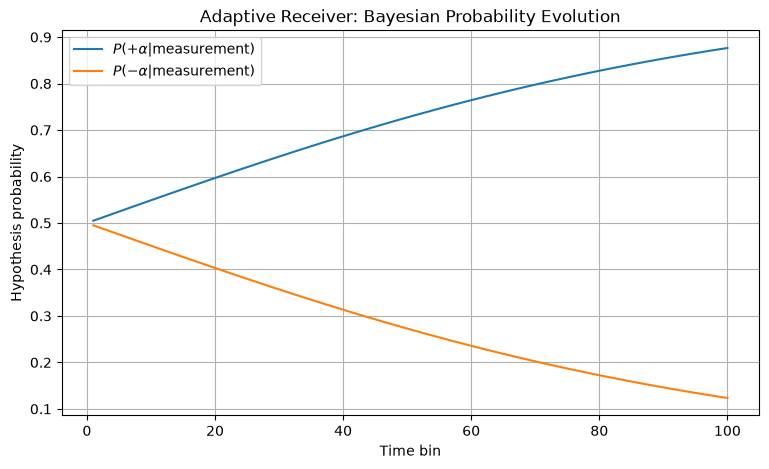

In [ ]:
time_bins = np.arange(1, M + 1)

plt.figure(figsize=(9, 5))

plt.plot(time_bins, history["P_plus"], label=r"$P(+\alpha|\mathrm{measurement})$")
plt.plot(time_bins, history["P_minus"], label=r"$P(-\alpha|\mathrm{measurement})$")

plt.xlabel("Time bin")
plt.ylabel("Hypothesis probability")
plt.title("Adaptive Receiver: Bayesian Probability Evolution")

plt.legend()
plt.grid()
plt.show()

In [ ]:
def calculate_adaptive_error(alpha, M, n_trials):
    """
    Calculate the error probability of the adaptive receiver.
    """

    errors = 0

    # Test |+alpha>

    for _ in range(n_trials):

        decision, _ = adaptive_receiver(true_state=+1, alpha=alpha, M=M)

        if decision != +1:

            errors += 1

    # Test |-alpha>

    for _ in range(n_trials):

        decision, _ = adaptive_receiver(true_state=-1, alpha=alpha, M=M)

        if decision != -1:

            errors += 1

    # Total number of experiments
    total_trials = 2 * n_trials

    return errors / total_trials

In [ ]:
P_error_adaptive = calculate_adaptive_error(alpha=alpha, M=M, n_trials=n_trials)

print("Adaptive receiver error probability =", P_error_adaptive)

Adaptive receiver error probability = 0.0703


In [ ]:
# Range of alpha values
alphas = np.linspace(0.1, 2.0, 25)

# Store adaptive receiver errors
P_adaptive = []

for alpha_value in alphas:

    error = calculate_adaptive_error(alpha=alpha_value, M=100, n_trials=2000)

    P_adaptive.append(error)

P_adaptive = np.array(P_adaptive)

In [ ]:
# Homodyne receiver
P_homodyne = (0.5*erfc(np.sqrt(2) * alphas))

# Kennedy receiver
P_kennedy = (0.5*np.exp(-4 * alphas**2))

# Helstrom bound
P_helstrom = (0.5*(1-np.sqrt(1-np.exp(-4 * alphas**2))))

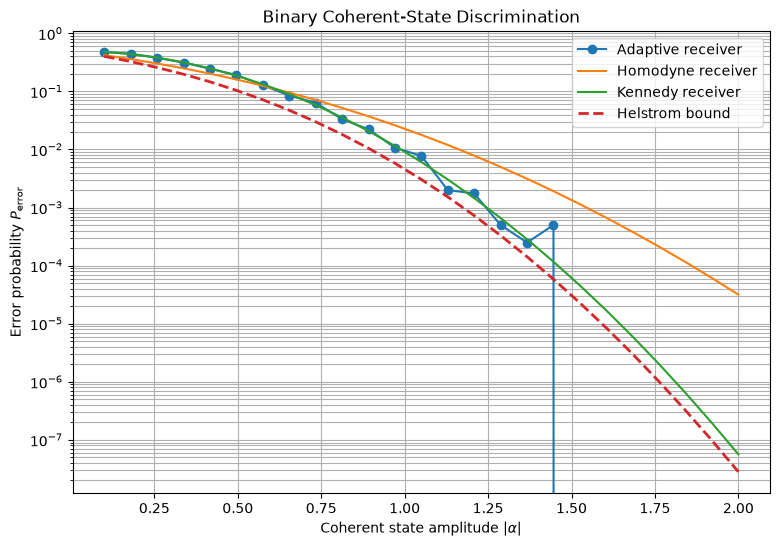

In [ ]:
plt.figure(figsize=(9, 6))

plt.semilogy(alphas, P_adaptive, "o-", label="Adaptive receiver")
plt.semilogy(alphas, P_homodyne, label="Homodyne receiver")
plt.semilogy(alphas, P_kennedy, label="Kennedy receiver")
plt.semilogy(alphas, P_helstrom, "--", linewidth=2, label="Helstrom bound")

plt.xlabel(r"Coherent state amplitude $|\alpha|$")
plt.ylabel(r"Error probability $P_{\mathrm{error}}$")
plt.title("Binary Coherent-State Discrimination")

plt.grid(True, which="both")
plt.legend()
plt.show()